# 🎗️ Meme Kanseri Teşhisi — Random Forest Sınıflandırma
**Veri Seti:** Breast Cancer Wisconsin Dataset  
**Yöntem:** Random Forest  
**Hedef:** Benign (iyi huylu) ve Malignant (kötü huylu) tümörleri ayırt etmek

## 1. Kütüphanelerin Yüklenmesi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

print('✅ Kütüphaneler başarıyla yüklendi.')

✅ Kütüphaneler başarıyla yüklendi.


## 2. Veri Setinin Yüklenmesi ve İncelenmesi

In [2]:
# Veri setini yükle
df = pd.read_csv('data.csv')

# Gereksiz sütunları kaldır
df.drop(columns=['id'], inplace=True, errors='ignore')

print('📊 Veri Seti Boyutu:', df.shape)
print('\n🔍 İlk 5 Satır:')
df.head()

📊 Veri Seti Boyutu: (569, 32)

🔍 İlk 5 Satır:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# Genel istatistikler
print('📈 Temel İstatistikler:')
df.describe()

📈 Temel İstatistikler:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [4]:
# Eksik değer kontrolü
print('❓ Eksik Değerler:')
print(df.isnull().sum())

# Sınıf dağılımı
print('\n🏷️ Sınıf Dağılımı:')
print(df['diagnosis'].value_counts())
print(f"  B (Benign - İyi Huylu):    {(df['diagnosis']=='B').sum()} örnek")
print(f"  M (Malignant - Kötü Huylu): {(df['diagnosis']=='M').sum()} örnek")

❓ Eksik Değerler:
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed: 32          

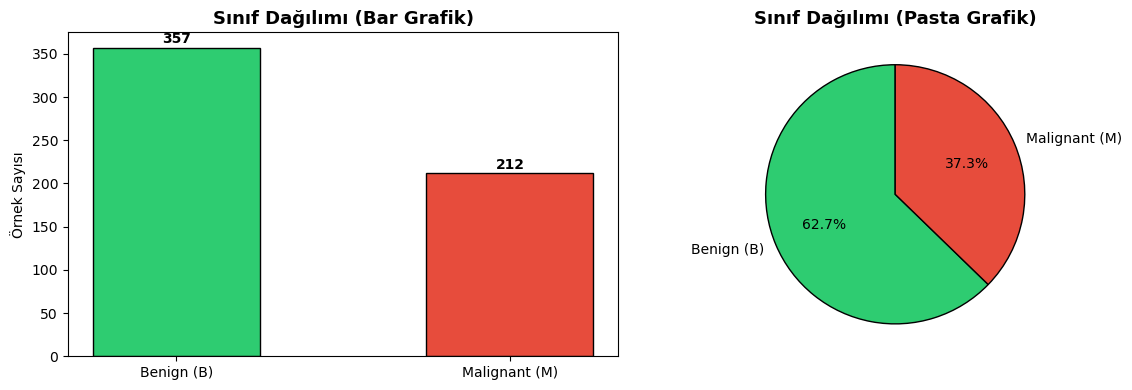

In [5]:
# Sınıf dağılımı görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar grafiği
counts = df['diagnosis'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Benign (B)', 'Malignant (M)'], counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Sınıf Dağılımı (Bar Grafik)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Örnek Sayısı')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pasta grafiği
axes[1].pie(counts.values, labels=['Benign (B)', 'Malignant (M)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Sınıf Dağılımı (Pasta Grafik)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Keşifsel Veri Analizi (EDA)

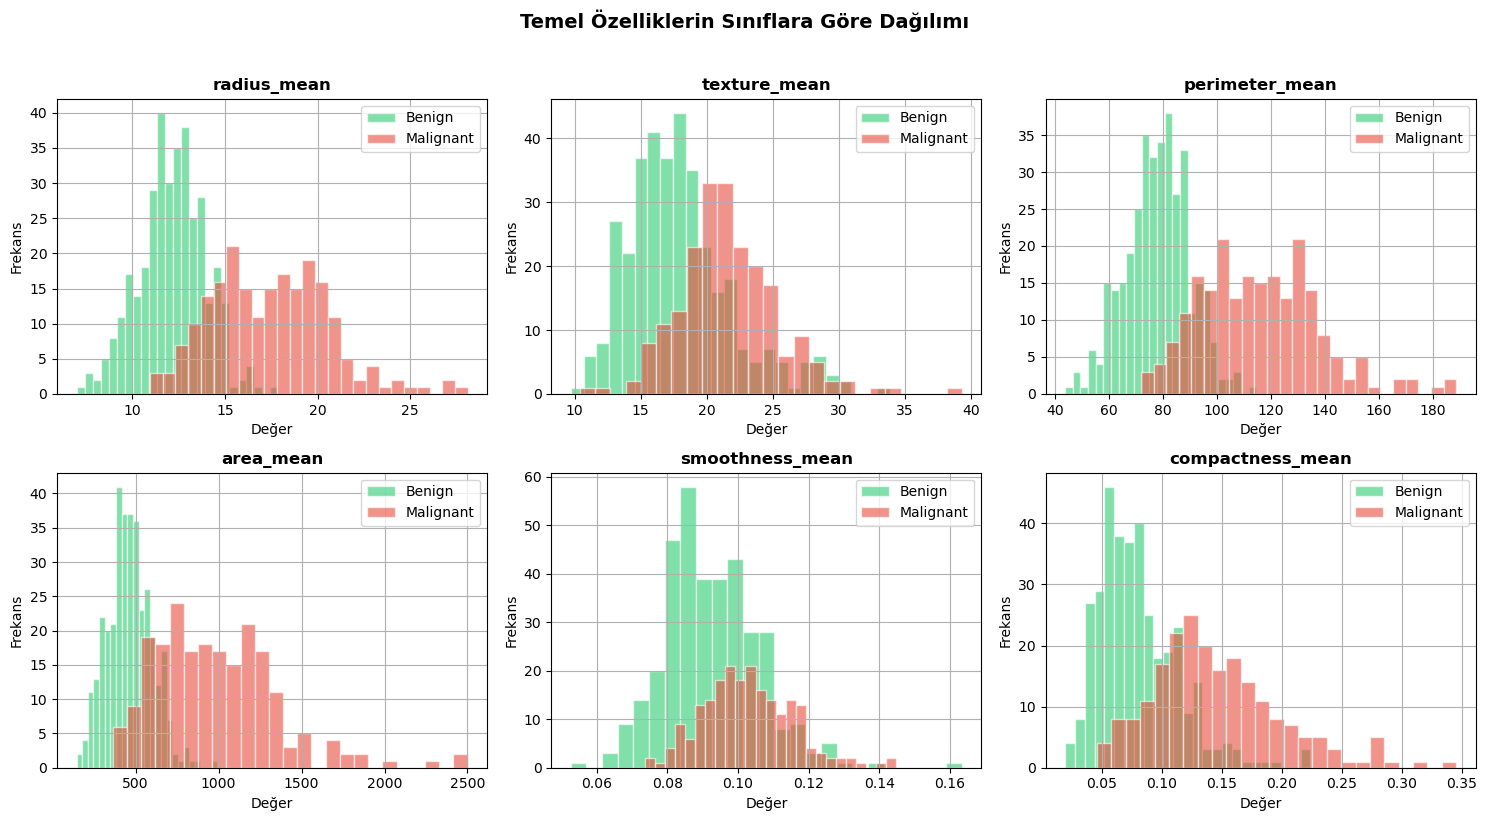

In [6]:
# Bazı temel özelliklerin dağılımı (mean değerler)
mean_features = ['radius_mean', 'texture_mean', 'perimeter_mean',
                 'area_mean', 'smoothness_mean', 'compactness_mean']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(mean_features):
    df[df['diagnosis']=='B'][feat].hist(ax=axes[i], alpha=0.6, color='#2ecc71',
                                         label='Benign', bins=25, edgecolor='white')
    df[df['diagnosis']=='M'][feat].hist(ax=axes[i], alpha=0.6, color='#e74c3c',
                                         label='Malignant', bins=25, edgecolor='white')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel('Değer')
    axes[i].set_ylabel('Frekans')

plt.suptitle('Temel Özelliklerin Sınıflara Göre Dağılımı', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

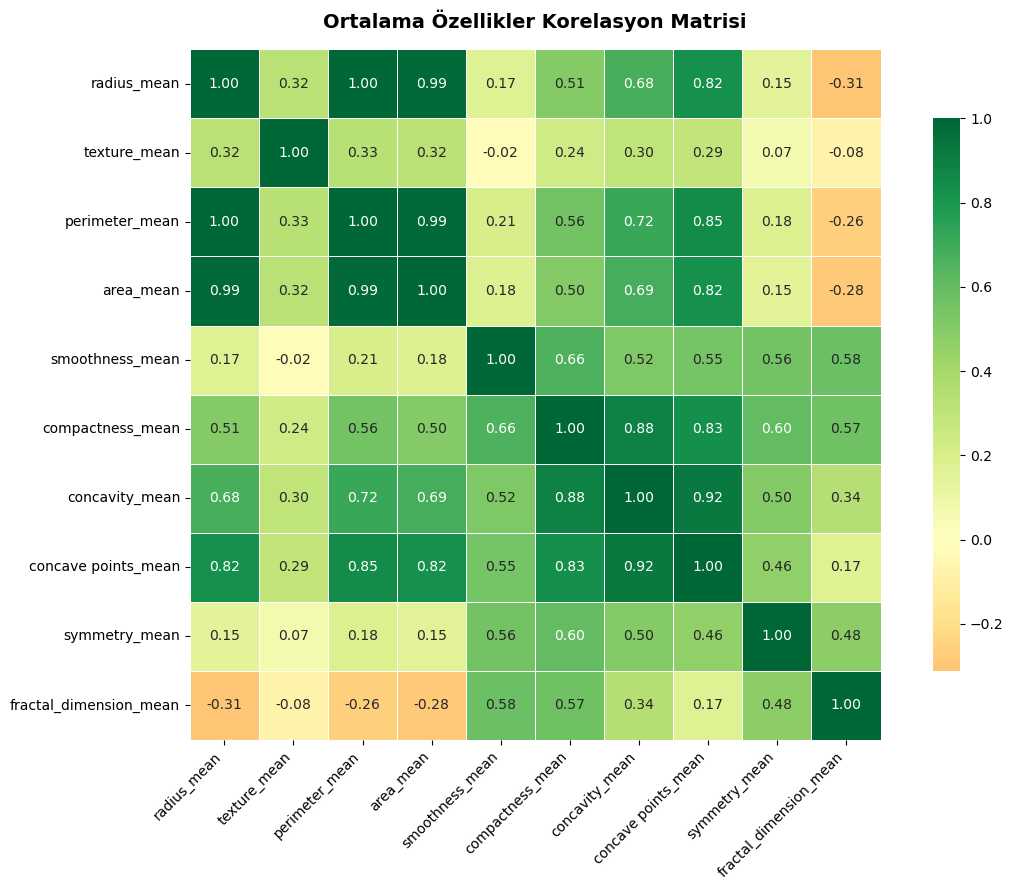

In [7]:
# Korelasyon ısı haritası (mean özellikler)
mean_cols = [c for c in df.columns if c.endswith('_mean')]
corr_matrix = df[mean_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Ortalama Özellikler Korelasyon Matrisi', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Veri Ön İşleme

In [8]:
# Hedef değişkeni encode et: M=1 (Malignant), B=0 (Benign)
le = LabelEncoder()
df['diagnosis_enc'] = le.fit_transform(df['diagnosis'])  # B=0, M=1

# Özellikler (X) ve hedef (y)
X = df.drop(columns=['diagnosis', 'diagnosis_enc'])
y = df['diagnosis_enc']

print('✅ Encoding tamamlandı: B=0 (Benign), M=1 (Malignant)')
print(f'   X boyutu: {X.shape}')
print(f'   y boyutu: {y.shape}')

✅ Encoding tamamlandı: B=0 (Benign), M=1 (Malignant)
   X boyutu: (569, 31)
   y boyutu: (569,)


In [9]:
# Eğitim / Test bölmesi (%80 - %20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('📦 Veri Bölme Sonuçları:')
print(f'   Eğitim seti : {X_train.shape[0]} örnek')
print(f'   Test seti   : {X_test.shape[0]} örnek')
print(f'\n   Eğitim seti sınıf dağılımı — Benign: {(y_train==0).sum()}, Malignant: {(y_train==1).sum()}')
print(f'   Test seti sınıf dağılımı   — Benign: {(y_test==0).sum()}, Malignant: {(y_test==1).sum()}')

📦 Veri Bölme Sonuçları:
   Eğitim seti : 455 örnek
   Test seti   : 114 örnek

   Eğitim seti sınıf dağılımı — Benign: 285, Malignant: 170
   Test seti sınıf dağılımı   — Benign: 72, Malignant: 42


## 5. Model Eğitimi — Random Forest

In [10]:
# Random Forest modeli oluştur ve eğit
rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 karar ağacı
    max_depth=None,      # Ağaçlar tam derinliğe kadar büyüsün
    min_samples_split=2,
    random_state=42,
    n_jobs=-1            # Tüm CPU çekirdeklerini kullan
)

rf_model.fit(X_train, y_train)
print('✅ Model eğitimi tamamlandı!')
print(f'   Kullanılan ağaç sayısı: {rf_model.n_estimators}')
print(f'   Özellik sayısı        : {rf_model.n_features_in_}')

✅ Model eğitimi tamamlandı!
   Kullanılan ağaç sayısı: 100
   Özellik sayısı        : 31


## 6. Model Değerlendirmesi

In [11]:
# Tahmin
y_pred = rf_model.predict(X_test)

# Metrikler
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print('=' * 45)
print('       📊 MODEL PERFORMANS METRİKLERİ')
print('=' * 45)
print(f'  Accuracy  (Doğruluk)   : %{accuracy*100:.2f}')
print(f'  Precision (Kesinlik)   : %{precision*100:.2f}')
print(f'  Recall    (Duyarlılık) : %{recall*100:.2f}')
print(f'  F1-Score               : %{f1*100:.2f}')
print('=' * 45)

print('\n📋 Detaylı Sınıflandırma Raporu:')
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))

       📊 MODEL PERFORMANS METRİKLERİ
  Accuracy  (Doğruluk)   : %96.49
  Precision (Kesinlik)   : %100.00
  Recall    (Duyarlılık) : %90.48
  F1-Score               : %95.00

📋 Detaylı Sınıflandırma Raporu:
               precision    recall  f1-score   support

   Benign (0)       0.95      1.00      0.97        72
Malignant (1)       1.00      0.90      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.95      0.96       114
 weighted avg       0.97      0.96      0.96       114



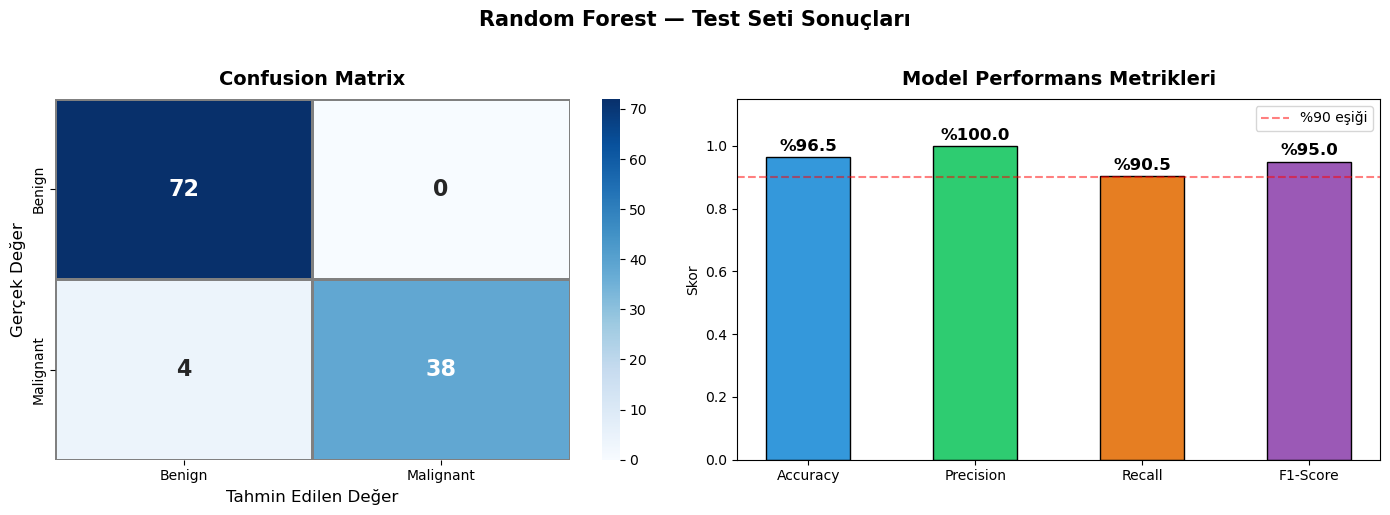

In [12]:
# Confusion Matrix görselleştirme
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'],
            ax=axes[0], linewidths=1, linecolor='gray',
            annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=10)
axes[0].set_ylabel('Gerçek Değer', fontsize=12)
axes[0].set_xlabel('Tahmin Edilen Değer', fontsize=12)

# Sağ: Metrik bar grafiği
metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1}
colors_bar = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
bars = axes[1].bar(metrics.keys(), metrics.values(), color=colors_bar,
                   edgecolor='black', width=0.5)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Model Performans Metrikleri', fontsize=14, fontweight='bold', pad=10)
axes[1].set_ylabel('Skor')
for bar, val in zip(bars, metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'%{val*100:.1f}', ha='center', fontweight='bold', fontsize=12)
axes[1].axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='%90 eşiği')
axes[1].legend()

plt.suptitle('Random Forest — Test Seti Sonuçları', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Feature Importance (Özellik Önemi)

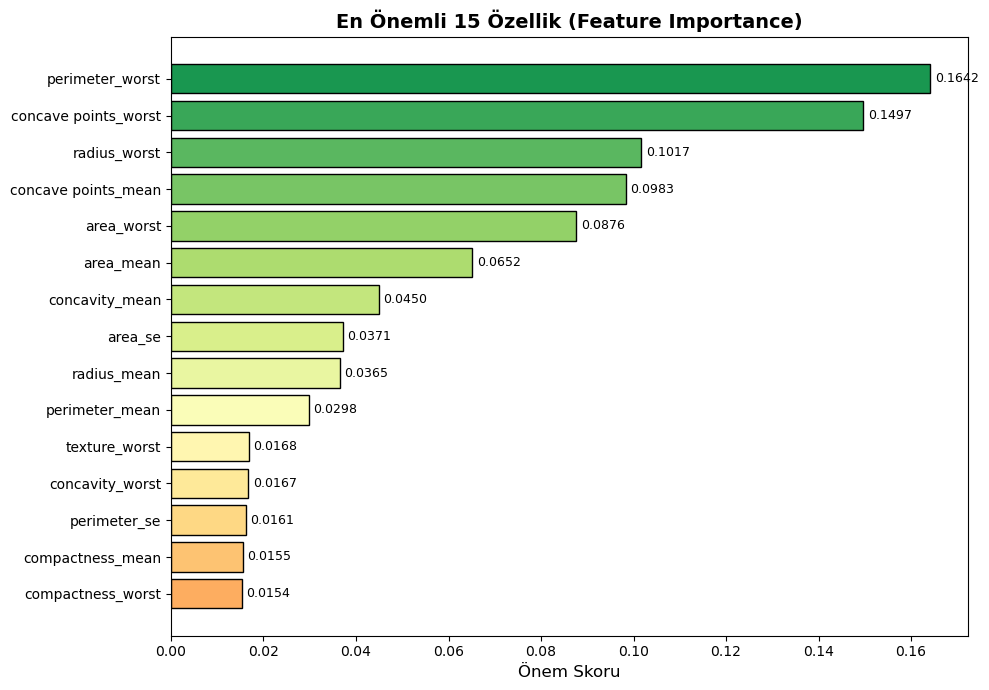


🥇 En Önemli 5 Özellik:
  1. perimeter_worst: 0.1642
  2. concave points_worst: 0.1497
  3. radius_worst: 0.1017
  4. concave points_mean: 0.0983
  5. area_worst: 0.0876


In [13]:
# Özellik önem skorları
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=True)

# En önemli 15 özellik
top15 = importances_sorted.tail(15)

plt.figure(figsize=(10, 7))
colors_imp = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top15)))
bars = plt.barh(top15.index, top15.values, color=colors_imp, edgecolor='black')
plt.xlabel('Önem Skoru', fontsize=12)
plt.title('En Önemli 15 Özellik (Feature Importance)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top15.values):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\n🥇 En Önemli 5 Özellik:')
for i, (feat, score) in enumerate(importances.sort_values(ascending=False).head(5).items(), 1):
    print(f'  {i}. {feat}: {score:.4f}')

## 8. Sonuç ve Yorum

In [14]:
print('=' * 55)
print('               📝 SONUÇ VE YORUM')
print('=' * 55)
print(f"""
Bu çalışmada Breast Cancer Wisconsin veri seti üzerinde
Random Forest algoritması ile ikili sınıflandırma yapılmıştır.

📌 Veri Seti:
   • Toplam 569 örnek, 30 özellik
   • Benign (B): {(y==0).sum()} örnek | Malignant (M): {(y==1).sum()} örnek
   • Eğitim/Test: %80 / %20 oranında bölünmüştür

📌 Model: Random Forest (100 karar ağacı)

📌 Sonuçlar:
   • Accuracy  (Doğruluk)   : %{accuracy*100:.2f}
   • Precision (Kesinlik)   : %{precision*100:.2f}
   • Recall    (Duyarlılık) : %{recall*100:.2f}
   • F1-Score               : %{f1*100:.2f}

📌 Yorum:
   Recall (Duyarlılık) tıbbi teşhis problemlerinde kritik
   öneme sahiptir. Yüksek Recall değeri, kötü huylu tümörlerin
   gözden kaçırılmadığını (Yanlış Negatif sayısının düşük
   olduğunu) göstermektedir. Elde edilen sonuçlar Random
   Forest'ın bu problem için oldukça başarılı olduğunu
   ortaya koymaktadır.
""")
print('=' * 55)

               📝 SONUÇ VE YORUM

Bu çalışmada Breast Cancer Wisconsin veri seti üzerinde
Random Forest algoritması ile ikili sınıflandırma yapılmıştır.

📌 Veri Seti:
   • Toplam 569 örnek, 30 özellik
   • Benign (B): 357 örnek | Malignant (M): 212 örnek
   • Eğitim/Test: %80 / %20 oranında bölünmüştür

📌 Model: Random Forest (100 karar ağacı)

📌 Sonuçlar:
   • Accuracy  (Doğruluk)   : %96.49
   • Precision (Kesinlik)   : %100.00
   • Recall    (Duyarlılık) : %90.48
   • F1-Score               : %95.00

📌 Yorum:
   Recall (Duyarlılık) tıbbi teşhis problemlerinde kritik
   öneme sahiptir. Yüksek Recall değeri, kötü huylu tümörlerin
   gözden kaçırılmadığını (Yanlış Negatif sayısının düşük
   olduğunu) göstermektedir. Elde edilen sonuçlar Random
   Forest'ın bu problem için oldukça başarılı olduğunu
   ortaya koymaktadır.

